### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_7446/3549569984.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


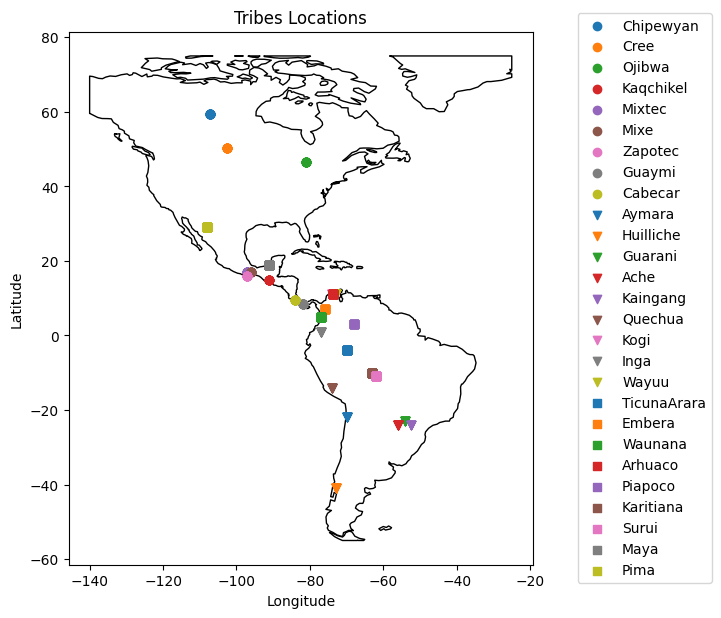

In [2]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6] # every lines, col 6
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
# loads land data (coordinates) of world map (set of polygons)
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

# creates plot
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

# crops desired area of subplot (not complete world map)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# for each tribe, plots a point (scatter)
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], # marker according to index
               color=colors_list[i%9], label=tribe)

# defines legends and shows
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [3]:
import numpy as np

# We remove all the columns except those for genetic markers
X = df.iloc[:,8:]

# Select the longitude column
y = df[['long']]

# Solving X.T * X * beta = X.T * y
beta = np.linalg.solve(X.T @ X, X.T @ y)

print(beta)

LinAlgError: Singular matrix

rank(X) - maximal number of linearly independent columns of A

We have $\text{rank}(X) < p$ so the columns of $X$ are linearly dependent, then $(X^\top X)$ is singular so it cannot be inverted.

Therefore np.linalg.solve fails with error `"Singular matrix"`.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [25]:
# We just change solve with lstsq (least-squares solution)
beta = np.linalg.lstsq(X.T @ X, X.T @ y)
beta

When using [`lstsq`](https://numpy.org/devdocs/reference/generated/numpy.linalg.lstsq.html) in place of `solve`, we get a solution at the end without any error.

It works because `lstsq` uses numerical methods based on $\textbf{SVD (singular value decomposition)}$ and doesn't require the matrix to be invertible.

> If a is square and of full rank, then x (but for round-off error) is the “exact” solution of the equation. Else, x minimizes the Euclidean 2-norm 
. If there are multiple minimizing solutions, the one with the smallest 2-norm 
 is returned.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [8]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
print(f'shape: {X.shape}')
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

shape: (494, 5709)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
lr.coef_

array([-0.03940988, -0.0245272 ,  0.01089763, ...,  0.04804479,
       -0.08985062,  0.01903025], shape=(5709,))

`sklearn` **recenters** predictors so that the intercept corresponds to the prediction when predictors are at their mean values, making it more interpretable and numerically stable.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

$\hookrightarrow$ Principal Component Analysis (PCA) is a method used to reduce the dimensionality of a dataset while keeping as much variability in the data as possible.

$\hookrightarrow$ From a geometric point of view, PCA finds new orthogonal directions (principal components) that maximize the variance of the data. These directions correspond to the eigenvectors of the covariance matrix, while the associated eigenvalues measure how much variance is explained by each component.

$\hookrightarrow$ From a statistical perspective, PCA transforms the original possibly correlated variables into a new set of uncorrelated variables that are linear combinations of the original variables. By keeping only the first few principal components (those with the largest eigenvalues), we can reduce the dimensionality of the data while preserving most of its variability.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

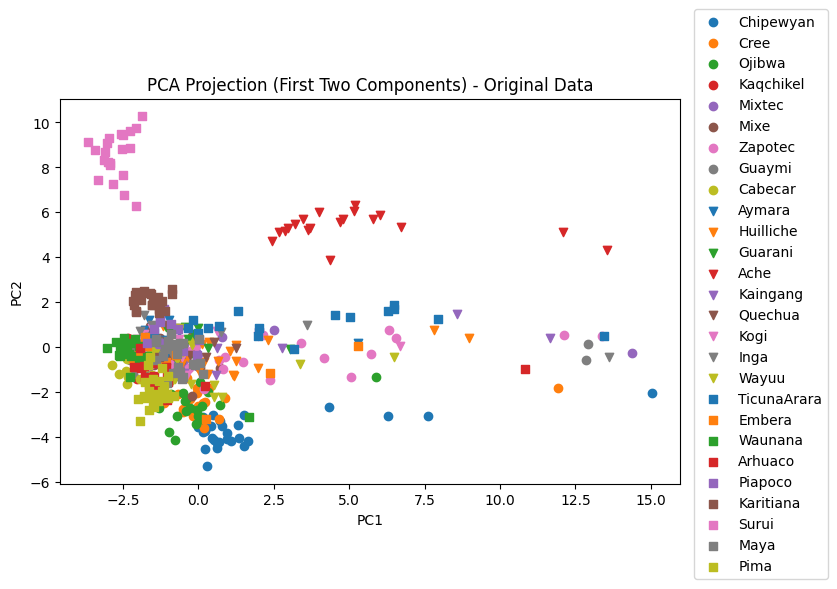

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

def pca_then_plot(X, title="PCA Projection (First Two Components)"):

    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8,5))

    for i, tribe in enumerate(df['Pop'].unique()):
        members = tribes == tribe
        plt.scatter(X_pca[members,0], X_pca[members,1],
                    marker=marker_list[i//9],
                    color=colors_list[i%9],
                    label=tribe)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.25,1.25))
    plt.show()
    
pca_then_plot(X, title="PCA Projection (First Two Components) - Original Data")


**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

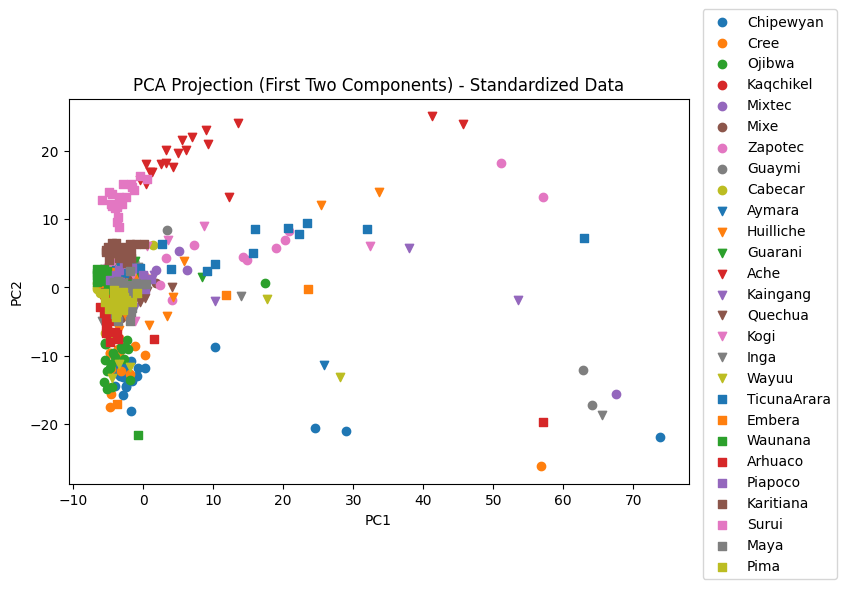

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

pca_then_plot(X_std, title="PCA Projection (First Two Components) - Standardized Data")

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

$\hookrightarrow$ Standardizing the data changes the PCA projection because PCA is sensitive to the scale of the variables.

$\hookrightarrow$ If variables have different variances, those with larger variance dominate the principal components. By standardizing the dataset, all variables have mean 0 and variance 1, so each genetic marker contributes equally to the PCA.

$\hookrightarrow$ Therefore, standardization is generally necessary when variables are measured on different scales or have very different variances. In this dataset, standardization allows PCA to capture the true structure of the genetic data rather than being dominated by markers with larger variance.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Total number of components: 494
For the first 2 PCs, the variance is: 3.3929133203688058 %
Components for 90% cummulative_variance: 376
Components for 95% cummulative_variance: 425


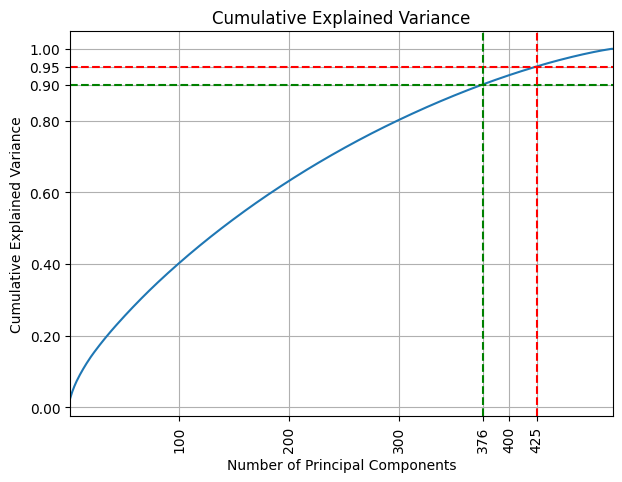

In [20]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_std)

explained_var_ratios = pca.explained_variance_ratio_
cummulative_explained_var_ratios = np.cumsum(explained_var_ratios)

# find number of components for 90% and 95%
q90 = np.argmax(cummulative_explained_var_ratios >= 0.90) + 1
q95 = np.argmax(cummulative_explained_var_ratios >= 0.95) + 1

print("Total number of components:", len(explained_var_ratios))
print("For the first 2 PCs, the variance is:",
      np.sum(explained_var_ratios[:2])*100, "%")
print("Components for 90% cummulative_variance:", q90)
print("Components for 95% cummulative_variance:", q95)

x = np.arange(1, len(cummulative_explained_var_ratios) + 1)

plt.figure(figsize=(7,5))
plt.plot(x, cummulative_explained_var_ratios)

plt.axhline(0.90, linestyle='--', color='green')
plt.axhline(0.95, linestyle='--', color='red')

plt.axvline(q90, linestyle='--', color='green')
plt.axvline(q95, linestyle='--', color='red')

# add ticks including q90 and q95
xticks = list(plt.xticks()[0])
xticks.extend([q90, q95])
plt.xticks(sorted(set(xticks)), rotation=90)

plt.yticks(np.arange(0, 1.1, 0.2).tolist() + [0.90, 0.95])

plt.xlim(1, len(x))

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid()
plt.show()

$\hookrightarrow$ The first two principal components capture approximately **3.4%** of the total variance.

$\hookrightarrow$ From the cumulative variance plot, we observe that approximately **400 principal components out of 492** are required to explain about **90–95%** of the total variance, and approximately **300 principal components** are needed to explain about **80%** of the total variance.

$\hookrightarrow$ This indicates that the variance in the dataset is distributed across many dimensions. Therefore, a relatively large number of principal components must be retained to preserve most of the variability in the data.

$\hookrightarrow$ Keeping around **400 principal components** provides a lower-dimensional representation of the genetic markers while preserving most of the information contained in the original dataset.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

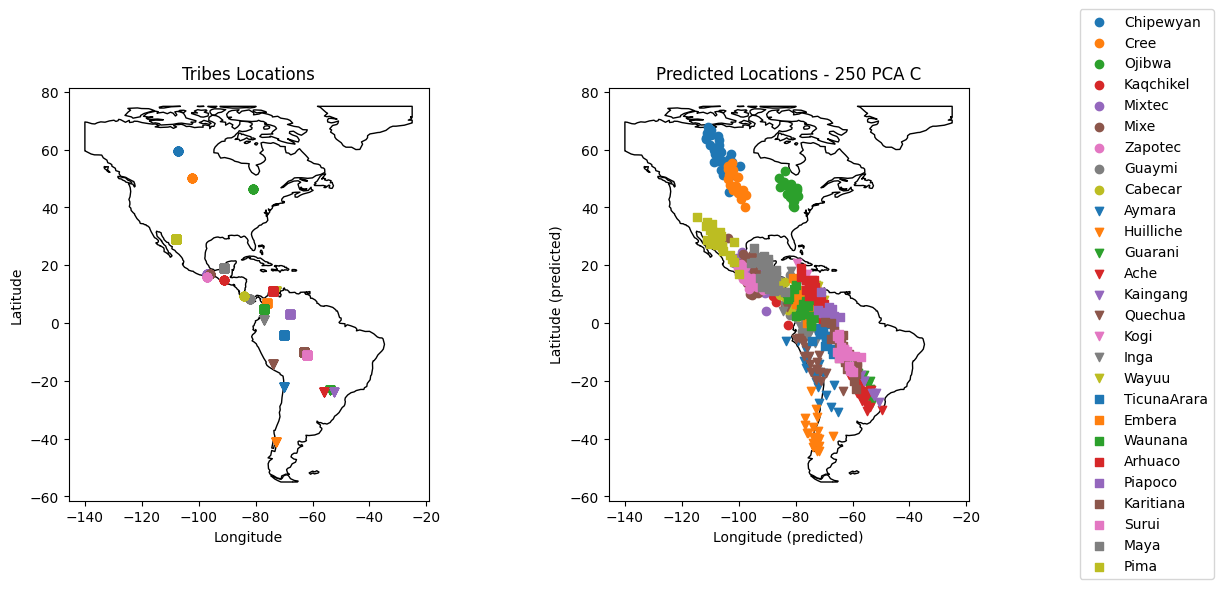

In [38]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# PCA with 250 components
pca = PCA(n_components=250)
X_pca = pca.fit_transform(X_std)

# targets
y_lat = df["lat"]
y_long = df["long"]

# regressions
reg_lat = LinearRegression()
reg_long = LinearRegression()

reg_lat.fit(X_pca, y_lat)
reg_long.fit(X_pca, y_long)

# predictions on y
lat_pred = reg_lat.predict(X_pca)
long_pred = reg_long.predict(X_pca)

# creates plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.0, 8.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

# crops desired area of subplot (not complete world map)
world.clip([-140, -55, -25, 75]).plot(ax=ax1, color='white', edgecolor='black')
world.clip([-140, -55, -25, 75]).plot(ax=ax2, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# Original position
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax1.scatter(
        members_tribe['long'], 
        members_tribe['lat'], 
        marker=marker_list[i//9], # marker according to index
        color=colors_list[i%9], 
        label=tribe
    )

# predicted position
for i, tribe in enumerate(df['Pop'].unique()):
    members = gdf['Pop'] == tribe
    ax2.scatter(
        long_pred[members],
        lat_pred[members],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe
    )

ax2.set_xlabel("Longitude (predicted)")
ax2.set_ylabel("Latitude (predicted)")
ax2.set_title("Predicted Locations - 250 PCA C")

# defines legends and shows
ax1.set_title('Tribes Locations')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.legend(loc='center right', bbox_to_anchor=(1.7, 0.5))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

$\hookrightarrow$ Using the first 250 PCA components, we performed principal components regression to predict the latitude and longitude of individuals from their genetic marckers. The predicted spatial coordinates show clusters that roughly resemble the original geographic distribution of populations. Individuals from the same population remain grouped together, and the overall structure appears similar to the original map.

$\hookrightarrow$ However, this result is somewhat **optimistic**. The regression model was trained and evaluated on the **same dataset**, meaning that the model may overfit the data. Because of this, the model may appear to predict geographic origin more accurately than it would for individuals outside the database.

$\hookrightarrow$ Therefore, the map may **overestimate the ability** to determine the geographical origin of new individuals based solely on their genetic markers. A proper evaluation would require testing the model on individuals that were not used during training.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [39]:
from sklearn.metrics.pairwise import haversine_distances

# Calculate the Haversine distances between predicted and actual coordinates
actual_coords = np.radians(df[['lat', 'long']].values)
predicted_coords = np.radians(np.array([lat_pred, long_pred]).T)
haversine_dist = haversine_distances(actual_coords, predicted_coords)
# Convert distances from radians to kilometers (Earth's radius ~ 6371 km)
R = 6371  # Earth radius in kilometers
haversine_dist_km = np.diag(haversine_dist) * R
print("Average Haversine distance (km):", np.mean(haversine_dist_km))

Average Haversine distance (km): 514.2267668618339


$\hookrightarrow$ The average Haversine distance between the real and predicted coordinates is approximately **500 km**. This metric quantifies the average error of the regression model in terms of geographic distance, providing a more interpretable measure of how well the model predicts the spatial coordinates based on genetic markers. On average, the predicted locations are about 500 km away from the actual locations, which indicates a moderate level of accuracy in predicting geographic origin based on genetic data.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

$\hookrightarrow$ Cross-validation is the principle of splitting the training set into $N$ different sets, using $N-1$ for training and $1$ for testing. We use this method to detect and prevent *overfitting* - simply learns each point, losing ability to generalize. Normally, we iterate over our folds to evaluate the model, and return the median error found in the testing set.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

$\hookrightarrow$ Given that our training set is grouped and that each tribe might have specific noise or variance in a given marker (given that they are genetically related), the choice for [**GroupKFold**](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html#groupkfold) seems adequate. By chosing this approach, we are able to "ignore" the inner noise into a tribe and see if the model was able to generalize the coorelation between markers and location.}

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

scaler = StandardScaler()
pca = PCA(n_components=4)

reg_lat = LinearRegression()
reg_long = LinearRegression()

est_lat = make_pipeline(scaler, pca, reg_lat)
est_long = make_pipeline(scaler, pca, reg_long)

reg_lat.fit(X_pca, y_lat)
reg_long.fit(X_pca, y_long)

# predictions on y
lat_pred = reg_lat.predict(X_pca)
long_pred = reg_long.predict(X_pca)



**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.